In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Salary_dataset.csv to Salary_dataset (1).csv


In [3]:
df = pd.read_csv("Salary_dataset.csv")
df.sample(5)

,Unnamed: 0,YearsExperience,Salary
15,15,5.0,67939.0
20,20,6.9,91739.0
18,18,6.0,81364.0
21,21,7.2,98274.0
9,9,3.8,57190.0


In [4]:
df = df.drop(columns = ["Unnamed: 0"])

In [5]:
df.head(
)

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [6]:
df.isnull().sum()

,0
YearsExperience,0
Salary,0


In [7]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
df.shape


(30, 2)

<Axes: xlabel='YearsExperience', ylabel='Salary'>

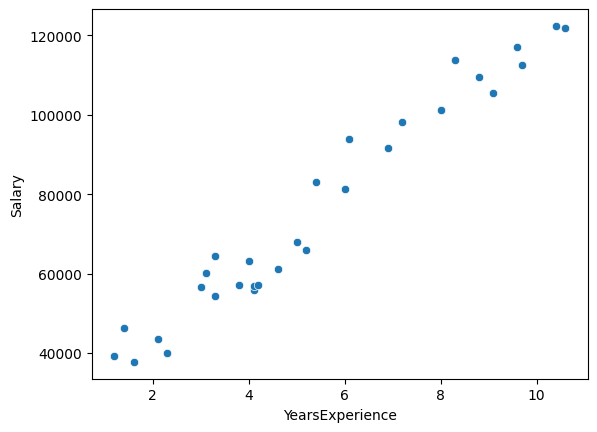

In [10]:
sns.scatterplot(x = df["YearsExperience"], y = df["Salary"])

<Axes: xlabel='YearsExperience', ylabel='Density'>

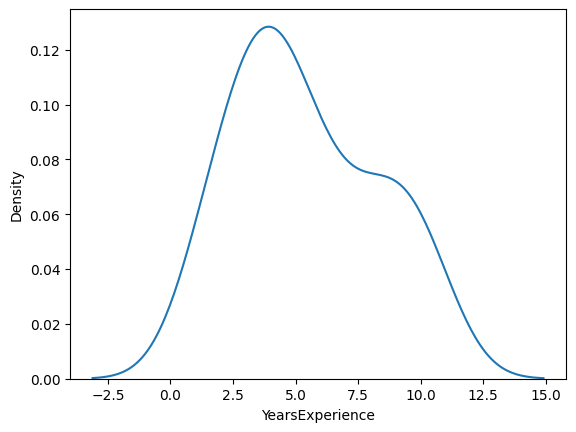

In [11]:
sns.kdeplot(df["YearsExperience"])

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df[['YearsExperience']], df['Salary'], test_size=0.2, random_state=42)

In [13]:

from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [14]:
trf = Pipeline([
    ('scaler', StandardScaler()),
    ('power', PowerTransformer(method = 'yeo-johnson')),
    ('model', LinearRegression())
])

In [15]:
trf.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('power', PowerTransformer()),
                ('model', LinearRegression())])

In [16]:
pred = trf.predict(X_test)

In [18]:
pred

array([112242.83118932,  75257.54948955, 102602.70103719,  79101.62891863,
        56903.00044468,  62611.98848173])

In [19]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

In [20]:
mse , r2

(46930080.11808453, 0.9081236241054288)